In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

DATASET_PATH = os.path.join('..', 'data', 'brain-tumor-mri-dataset')

print(f"Veri Seti Yolu: {DATASET_PATH}")

# Klasör kontrolü
if os.path.exists(DATASET_PATH):
    print("Veri seti bulundu")
    # Eğitim ve Test klasörlerini görelim
    print("İçerik:", os.listdir(DATASET_PATH))
else:
    print("HATA: Veri seti bulunamadı")

Veri Seti Yolu: ..\data\brain-tumor-mri-dataset
Veri seti bulundu
İçerik: ['Testing', 'Training']


In [5]:
# Eğitim ve Test klasör yollarını belirleme
train_dir = os.path.join(DATASET_PATH, 'Training')
test_dir = os.path.join(DATASET_PATH, 'Testing')

print("Eğitim seti yolu:", train_dir)
print("Test seti yolu:", test_dir)

Eğitim seti yolu: ..\data\brain-tumor-mri-dataset\Training
Test seti yolu: ..\data\brain-tumor-mri-dataset\Testing


In [8]:
import os

train_dir = os.path.join(DATASET_PATH, 'Training')
test_dir = os.path.join(DATASET_PATH, 'Testing')

print("Eğitim Yolu:", train_dir)
print("Test Yolu:", test_dir)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    seed=123,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    seed=123
)

class_names = train_ds.class_names
print(f"\nSınıflar: {class_names}")

train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Eğitim Yolu: ..\data\brain-tumor-mri-dataset\Training
Test Yolu: ..\data\brain-tumor-mri-dataset\Testing
Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.

Sınıflar: ['glioma', 'meningioma', 'notumor', 'pituitary']


# **Custom CNN**

In [9]:
from tensorflow.keras import Input, layers, models

def create_modern_model(input_shape, num_classes):
    inputs= Input(shape=input_shape)

    #Data Augmentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    x = layers.Rescaling(1./255)(x)

    #1
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)  #64*64

    #2
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x) #32*32

    #3
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x) #16*16

    #4
    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    outputs =layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)
model = create_modern_model(input_shape=(128,128,3) , num_classes=4)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
    

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             

 Total params: 390,884 (1.49 MB)

 Trainable params: 389,924 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks=[
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('brain_tumor_model.keras', save_best_only=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

In [6]:
history= model.fit(
    train_ds,
    validation_data=val_ds,
    epochs= 20,
    callbacks = callbacks
)

Epoch 1/20


I0000 00:00:1765879355.470290      76 cuda_dnn.cc:529] Loaded cuDNN version 90300


179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6347 - loss: 0.8745
Epoch 1: val_loss improved from inf to 2.81497, saving model to brain_tumor_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 0.6350 - loss: 0.8740 - val_accuracy: 0.2410 - val_loss: 2.8150 - learning_rate: 0.0010
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7454 - loss: 0.6397
Epoch 2: val_loss improved from 2.81497 to 1.60505, saving model to brain_tumor_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.7455 - loss: 0.6396 - val_accuracy: 0.3623 - val_loss: 1.6050 - learning_rate: 0.0010
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7694 - loss: 0.5625
Epoch 3: val_loss improved from 1.60505 to 1.08795, saving model to brain_tumor_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.7695 - loss: 0.5625 - val_accuracy: 0.6445 - val_loss: 1.0880 - learning_rate: 0.0010
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/ste

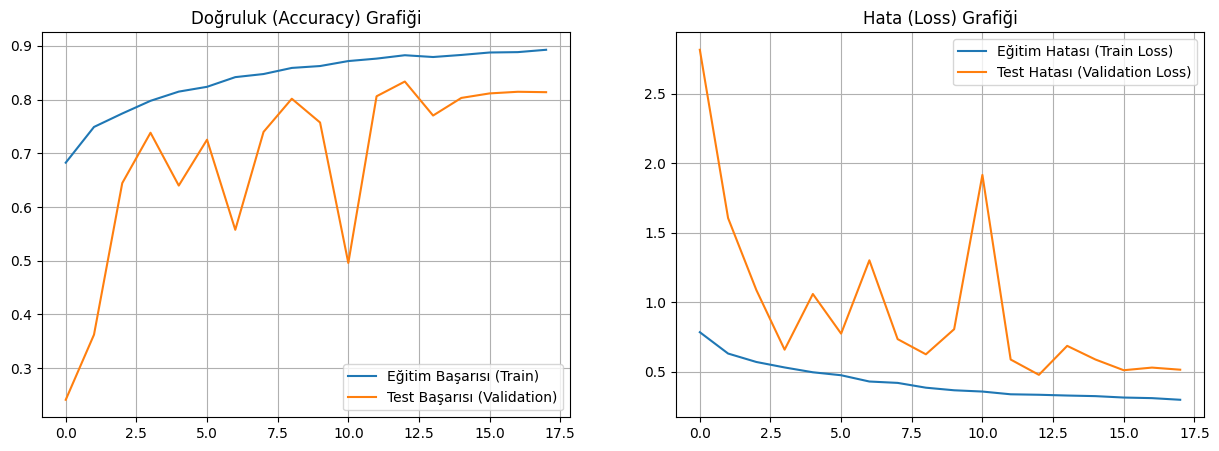

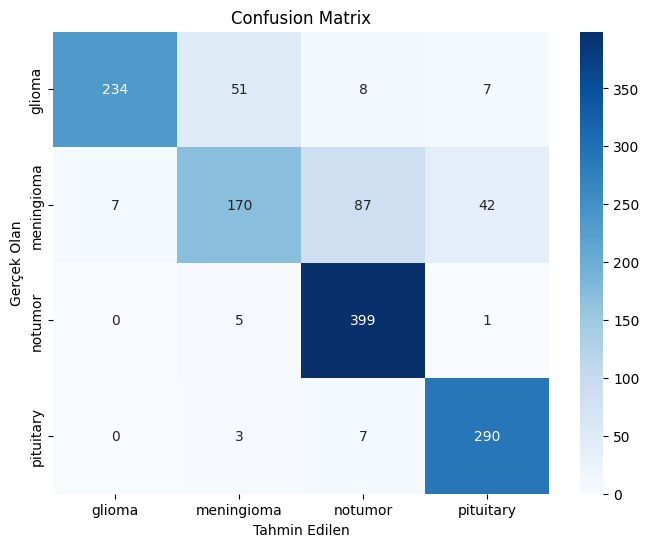

              precision    recall  f1-score   support

      glioma       0.97      0.78      0.87       300
  meningioma       0.74      0.56      0.64       306
     notumor       0.80      0.99      0.88       405
   pituitary       0.85      0.97      0.91       300

    accuracy                           0.83      1311
   macro avg       0.84      0.82      0.82      1311
weighted avg       0.84      0.83      0.83      1311



In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Learning Curve
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

# Doğruluk Grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarısı (Train)')
plt.plot(epochs_range, val_acc, label='Test Başarısı (Validation)')
plt.legend(loc='lower right')
plt.title('Doğruluk (Accuracy) Grafiği')
plt.grid(True)

# Hata Grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Hatası (Train Loss)')
plt.plot(epochs_range, val_loss, label='Test Hatası (Validation Loss)')
plt.legend(loc='upper right')
plt.title('Hata (Loss) Grafiği')
plt.grid(True)
plt.show()

#Confusion Matrix
y_gercekler = []
y_tahminler = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
   
    predicted_classes = np.argmax(preds, axis=1)
    
    y_gercekler.extend(labels.numpy())
    y_tahminler.extend(predicted_classes)

cm = confusion_matrix(y_gercekler, y_tahminler)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Olan')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_gercekler, y_tahminler, target_names=class_names))

# **VGG16 + Transfer Learning + FineTune**

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, Input, optimizers

def create_finetune_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.Rescaling(1./255)(x)

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    base_model.trainable = True 
    for layer in base_model.layers:
        if 'block5' in layer.name:
            layer.trainable = True
        else:
            layer.trainable = False

    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)


finetune_model = create_finetune_model(input_shape=(128, 128, 3), num_classes=4)

finetune_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), # 0.00001
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

finetune_model.summary()

history_finetune = finetune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,740 (56.14 MB)

 Trainable params: 7,081,476 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4265 - loss: 1.2837
Epoch 1: val_loss did not improve from 0.47813
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 83ms/step - accuracy: 0.4274 - loss: 1.2821 - val_accuracy: 0.7742 - val_loss: 0.6001 - learning_rate: 1.0000e-05
Epoch 2/20
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8003 - loss: 0.5323
Epoch 2: val_loss did not improve from 0.47813
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.8005 - loss: 0.5319 - val_accuracy: 0.8200 - val_loss: 0.4814 - learning_rate: 1.0000e-05
Epoch 3/20
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8552 - loss: 0.3990
Epoch 3: val_loss improved from 0.47813 to 0.39864, saving model to brain_tumor_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.8553 - loss: 0.3988 - val_accuracy: 0.8513 - val_loss: 0.3986 - learning_rate: 1.0000e-05
Epoch 4/20
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8742 - loss: 0.3371
Epoch 4: val_loss improve

              precision    recall  f1-score   support

      glioma       0.96      0.92      0.94       300
  meningioma       0.92      0.91      0.91       306
     notumor       0.96      1.00      0.98       405
   pituitary       0.97      0.98      0.98       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



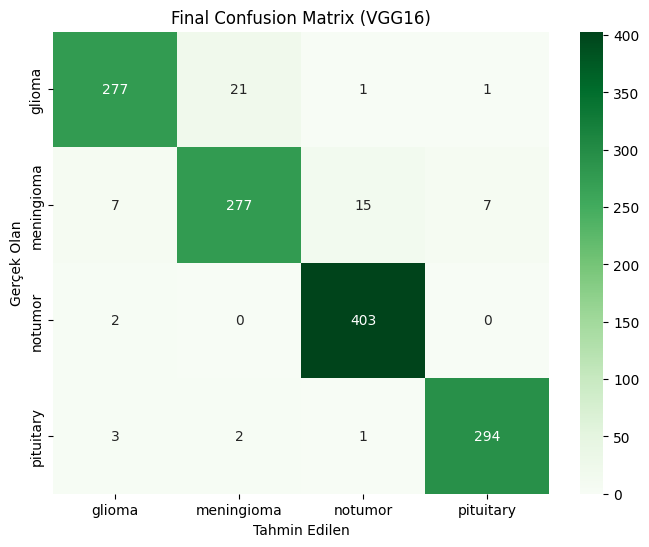

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_gercekler = []
y_tahminler = []

for images, labels in val_ds:
    preds = finetune_model.predict(images, verbose=0)
    predicted_classes = np.argmax(preds, axis=1)
    y_gercekler.extend(labels.numpy())
    y_tahminler.extend(predicted_classes)

print(classification_report(y_gercekler, y_tahminler, target_names=class_names))

cm = confusion_matrix(y_gercekler, y_tahminler)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Olan')
plt.title('Final Confusion Matrix (VGG16)')
plt.show()